# Ejercicios prácticos - Módulo 3

In [ ]:
import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pymc as pm
from scipy.special import expit as logistic
import graphviz
import os
os.environ["PATH"] += os.pathsep + 'C:/Program Files/Graphviz/bin/'

### 1. Escribir el teorema de Bayes para un modelo jerárquico.

Para escribir el teorema de Bayes en versión jerárquica **voy a trabajar un modelo de dos niveles**, creo que viendo primero ese caso luego podemos entender su extensión a **n-niveles**. Para esto tenemos que suponer grupos $i=1,\dots,G$ con observaciones $\mathbf{x}_i=\{x_{ij}\}_{j=1}^{n_i}$. Cada grupo tiene su propio parámetro $\theta_i$ y todos los $\theta_i$ comparten una estructura común descrita por hiperparámetros $\psi$.

**Luego, motivados por el principio de intercambiabilidad (o teorema de De Finetti) asumimos que:**

1. Dentro de cada grupo los $x_{ij}$ son condicionalmente independientes dado $\theta_i$:

  $$p(\mathbf{x}_i\mid\theta_i)=\prod_j p(x_{ij}\mid\theta_i)$$

2. Entre grupos, los parámetros son intercambiables:

  $$p(\boldsymbol{\theta}\mid\psi)=\prod_i p(\theta_i\mid\psi)$$

**Con todo esto tenemos que el teorema de Bayes jerárquico es de la forma:**

$$
p(\boldsymbol{\theta},\psi\mid \mathbf{x})
=\frac{
\Big[\prod_{i=1}^G \prod_{j=1}^{n_i} p(x_{ij}\mid \theta_i)\Big]
\Big[\prod_{i=1}^G p(\theta_i\mid \psi)\Big]\,
p(\psi)
}{
p(\mathbf{x})
},
$$

Donde la **evidencia ($x$)** ahora integra *todos* los niveles:

$$
p(\mathbf{x})
=\iint
\Big[\prod_{i=1}^G \prod_{j=1}^{n_i} p(x_{ij}\mid \theta_i)\Big]
\Big[\prod_{i=1}^G p(\theta_i\mid \psi)\Big]\,
p(\psi)
\; d\boldsymbol{\theta}\, d\psi .
$$

Aquí es donde se puede ver más claramente **la trampa** que podemos hacer a partir de usar **el teorema de De Finetti**: este no nos dice
que tomar como prior, ni como parámetro ni como verosimilitud y por ende tomamos como parámetro a un grupo de parámetros y como prior de
dichos parámetros volvemos a aplicar el teorema de vuelta. **Podemos seguir así por cada nivel jerárquico que tengamos** en los datos y lo que
ocurrirá es que tendremos expresiones más complejas y la evidencia ($x$) va a integrar a más dimensiones.

A modo de "mapa mental" podemos pensar en la siguiente proporcionalidad:

$$
\boxed{
p(\text{todos los parámetros}\mid \text{datos})
\propto
\underbrace{p(\text{datos}\mid \text{parámetros de grupo})}_{\text{likelihood}}
\;\underbrace{p(\text{parámetros de grupo}\mid \text{hiperparámetros})}_{\text{prior condicional}}
\; \underbrace{p(\text{hiperparámetros})}_{\text{hiperprior}}.
}
$$

### 2. Describí un ejemplo donde un modelo jerárquico sea más adecuado que un modelo no-jerárquico. Explicá cómo se estructuraría el modelo, incluyendo los niveles de la jerarquía y las dependencias entre los parámetros.

Un caso donde sería más pertinente el uso de un modelo jerárquico sobre uno no jerárquico **podría ser un caso de análisis salarial**. Por ejemplo si quisieramos analizar salarios en el campo de la tecnología pero en [el conjunto de datos](https://www.kaggle.com/datasets/yusufdelikkaya/datascience-salaries-2024) donde tenemos dicha información también tenemos información sobre la residencia del empleado y su seniority esta información podría ser más útil a la hora de estimar el salario ya que son grupos que sabemos perfectamente que influyen en nuestros datos.

* Si ajustamos un **modelo no jerárquico** en donde separamos en grupos residencia-seniority (ej: Argentina-Junior) enfrentaríamos un riesgo de sobreajuste ya que eventualmente tendremos grupos pequeños en donde nuestro modelo se aprenderá los datos de memoria.

* Si ajustamos un **modelo no jerárquico** en donde consideramos a todos los datos como un grupo entonces obtendríamos el caso contrario, sub-ajuste por parte del modelo. Seguramente este lanzará estimaciones basadas en las poblaciones más grandes (ej: paises desarrollados con mayor infraestructura en tecnología) e ignorará a los grupos pequeños obteniendo así estimaciones erróneas.

* Finalmente, si ajustamos un **modelo jerárquico** entonces consideraríamos un único proceso generador de los salarios inherente al sector tecnológico.Tendríamos niveles para la residencia y más abajo el seniority agrupado por la residencia como otro nivel más, teniendo asi estimaciones más precisas y logrando vivir en el punto medio de los dos casos explicados antes.

A continuación dejo un gráfico haciendo uso de grafos similares a los de PyMC para explicar como se estructuraría este modelo:

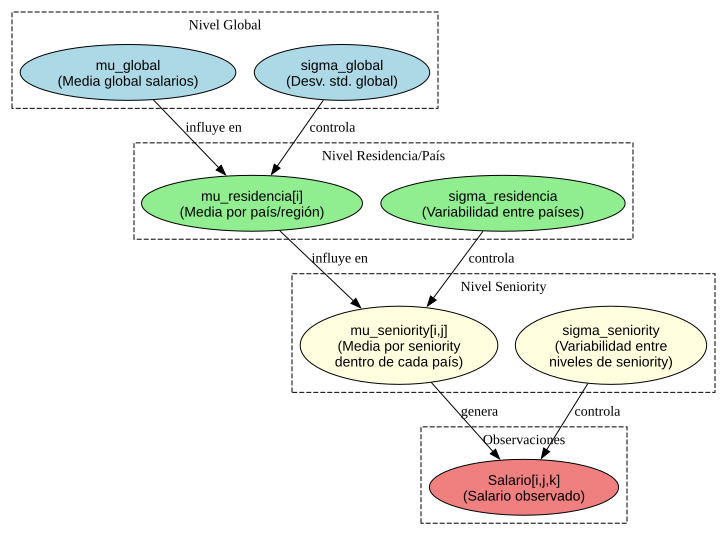

In [ ]:
# Crear gráfico del modelo jerárquico para análisis salarial
dot = graphviz.Digraph(comment='Modelo Jerárquico - Análisis Salarial')
dot.attr(rankdir='TB')

# Configurar estilo general
dot.attr('node', shape='ellipse', style='filled', fontname='Arial')

# Hiperparámetros globales (nivel más alto)
dot.node('mu_global', 'mu_global\n(Media global salarios)', fillcolor='lightblue')
dot.node('sigma_global', 'sigma_global\n(Desv. std. global)', fillcolor='lightblue')

# Parámetros de residencia (segundo nivel)
dot.node('mu_residencia', 'mu_residencia[i]\n(Media por país/región)', fillcolor='lightgreen')
dot.node('sigma_residencia', 'sigma_residencia\n(Variabilidad entre países)', fillcolor='lightgreen')

# Parámetros de seniority dentro de cada residencia (tercer nivel)
dot.node('mu_seniority', 'mu_seniority[i,j]\n(Media por seniority\ndentro de cada país)', fillcolor='lightyellow')
dot.node('sigma_seniority', 'sigma_seniority\n(Variabilidad entre\nniveles de seniority)', fillcolor='lightyellow')

# Observaciones (salarios individuales)
dot.node('salario', 'Salario[i,j,k]\n(Salario observado)', fillcolor='lightcoral')

# Conexiones jerárquicas
dot.edge('mu_global', 'mu_residencia', label='influye en')
dot.edge('sigma_global', 'mu_residencia', label='controla')
dot.edge('mu_residencia', 'mu_seniority', label='influye en')
dot.edge('sigma_residencia', 'mu_seniority', label='controla')
dot.edge('mu_seniority', 'salario', label='genera')
dot.edge('sigma_seniority', 'salario', label='controla')

# Añadir subgrafos para organizar mejor la visualización
with dot.subgraph(name='cluster_global') as c:
    c.attr(label='Nivel Global', style='dashed')
    c.node('mu_global')
    c.node('sigma_global')

with dot.subgraph(name='cluster_residencia') as c:
    c.attr(label='Nivel Residencia/País', style='dashed')
    c.node('mu_residencia')
    c.node('sigma_residencia')

with dot.subgraph(name='cluster_seniority') as c:
    c.attr(label='Nivel Seniority', style='dashed')
    c.node('mu_seniority')
    c.node('sigma_seniority')

with dot.subgraph(name='cluster_obs') as c:
    c.attr(label='Observaciones', style='dashed')
    c.node('salario')

dot

### 3. Tenés datos de ventas mensuales de diferentes sucursales de una cadena de supermercados. El objetivo es construir un modelo jerárquico para predecir las ventas futuras y entender la variabilidad entre sucursales. Realizá un esquema de como podría ser un modelo de ese tipo.

Para plantear este modelo jerárquico podemos basarnos en las siguientes hipótesis:

1. Hay una cadena de supermercados que relaciona a todas las sucursales, por lo tanto es correcto pensar que hay un proceso generador
común en las ventas mensuales.

2. Cada sucursal está en una locación diferente que tiene un mayor/menor volumen de ventas y eso influye en la variabilidad de las mismas.
Podemos considerarlas como el siguiente nivel en la jerarquía.

3. Luego dentro de cada sucursal tenemos información sobre ventas por cada mes y sabemos que la estacionalidad influye también en la variabilidad.
Podemos considerar a los meses como un nivel más abajo en la jerarquía, siendo agrupados por sucursal.

Considerando estas 3 hipótesis para nuestro modelo podemos modelar la estructura jerárquica y obtener buenas predicciones a futuro. A continuación dejo un gráfico haciendo uso de grafos similares a los de PyMC para explicar como se estructuraría este modelo:

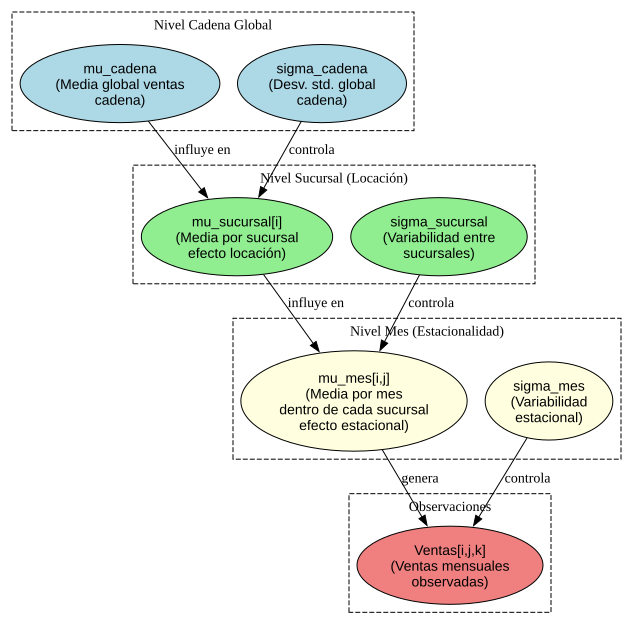

In [ ]:
# Crear gráfico del modelo jerárquico para ventas de supermercados
dot_super = graphviz.Digraph(comment='Modelo Jerárquico - Ventas Supermercados')
dot_super.attr(rankdir='TB')

# Configurar estilo general
dot_super.attr('node', shape='ellipse', style='filled', fontname='Arial')

# Hiperparámetros globales (nivel más alto) - Cadena de supermercados
dot_super.node('mu_cadena', 'mu_cadena\n(Media global ventas\ncadena)', fillcolor='lightblue')
dot_super.node('sigma_cadena', 'sigma_cadena\n(Desv. std. global\ncadena)', fillcolor='lightblue')

# Parámetros de sucursal (segundo nivel)
dot_super.node('mu_sucursal', 'mu_sucursal[i]\n(Media por sucursal\nefecto locación)', fillcolor='lightgreen')
dot_super.node('sigma_sucursal', 'sigma_sucursal\n(Variabilidad entre\nsucursales)', fillcolor='lightgreen')

# Parámetros de mes/estacionalidad dentro de cada sucursal (tercer nivel)
dot_super.node('mu_mes', 'mu_mes[i,j]\n(Media por mes\ndentro de cada sucursal\nefecto estacional)', fillcolor='lightyellow')
dot_super.node('sigma_mes', 'sigma_mes\n(Variabilidad\nestacional)', fillcolor='lightyellow')

# Observaciones (ventas mensuales individuales)
dot_super.node('ventas', 'Ventas[i,j,k]\n(Ventas mensuales\nobservadas)', fillcolor='lightcoral')

# Conexiones jerárquicas
dot_super.edge('mu_cadena', 'mu_sucursal', label='influye en')
dot_super.edge('sigma_cadena', 'mu_sucursal', label='controla')
dot_super.edge('mu_sucursal', 'mu_mes', label='influye en')
dot_super.edge('sigma_sucursal', 'mu_mes', label='controla')
dot_super.edge('mu_mes', 'ventas', label='genera')
dot_super.edge('sigma_mes', 'ventas', label='controla')

# Añadir subgrafos para organizar mejor la visualización
with dot_super.subgraph(name='cluster_cadena') as c:
    c.attr(label='Nivel Cadena Global', style='dashed')
    c.node('mu_cadena')
    c.node('sigma_cadena')

with dot_super.subgraph(name='cluster_sucursal') as c:
    c.attr(label='Nivel Sucursal (Locación)', style='dashed')
    c.node('mu_sucursal')
    c.node('sigma_sucursal')

with dot_super.subgraph(name='cluster_mes') as c:
    c.attr(label='Nivel Mes (Estacionalidad)', style='dashed')
    c.node('mu_mes')
    c.node('sigma_mes')

with dot_super.subgraph(name='cluster_ventas') as c:
    c.attr(label='Observaciones', style='dashed')
    c.node('ventas')

dot_super

### 4. Supongamos que nos piden analizar datos sobre la calidad del agua en una ciudad. Los datos correponden a mediciones de plomo en agua tomadas en varios puntos de la ciudad. Los datos están agrupados por barrios y las muestras con concentraciones de plomo por encima de las recomendaciones de la Organización Mundial de la Salud se marcan con 0 y las muestras con valores por debajo de las recomendaciones se marcan con 1. Este es un escenario muy simple, en un ejemplo más realista, posiblemente tendríamos una medición continua de la concentración de plomo y probablemente muchos más grupos.

Para el ejercicio se consideran los siguientes datos ficticios:

In [ ]:
N = [30, 30, 30]
G = [18, 18, 18]

group_idx = np.repeat(np.arange(len(N)), N)

data = []
for i in range(0, len(N)):
    data.extend(np.repeat([1, 0], [G[i], N[i]-G[i]]))

#### a. Usando notación estadística escribí un modelo jerárquico para este problema.

En este caso estamos ante una salida binaria para la variable objetivo: 0 o 1. Lo ideal para este caso sería modelarla usando una distribución **Bernoulli** y nuestra tarea sería estimar el parámetro $\theta$ que corresponde a la probabilidad de tener agua limpia dado un barrio.

Tomando esto en cuenta y que además es un modelo jerárquico considero la siguiente estructura:

* $\mu_p \sim Beta(1, 1)$
* $\mu_p \sim HalfNormal(1, 1)$
* $\theta_i \sim Beta(\mu_p, \mu_p)$
* $y_i \sim Bernoulli(\theta_i)$

Este caso es similar al de **la moneda** que se vió en guías anteriores pero ahora añadiendo **hiperpriors** a $\theta$. Aquí la diferencia
es que para $\theta$ en vez de definir su prior en función de $\alpha$ y $\beta$ lo hacemos en términos de  $\mu$ (media) y $\nu$ (precisión) ya que estos resultan más intuitivos de cara a la interpretación posterior del modelo.

#### b. Usando PyMC implementá el modelo del apartado anterior.

In [ ]:
with pm.Model() as model_water_quality:
    # Hiperpriors
    mu_p = pm.Beta("mu_p", alpha=1, beta=1)
    nu_p = pm.HalfNormal("nu_p", sigma=10)

    # Priors
    theta_barrio = pm.Beta("theta_barrio", mu=mu_p, nu=nu_p, shape=len(N))

    # Likelihood
    y = pm.Bernoulli("y", p=theta_barrio[group_idx], observed=data)

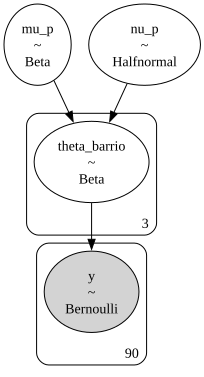

In [ ]:
model_water_quality.to_graphviz()

#### c. Ejecutá el modelo de PyMC 3 veces, resumí los resultados y explicá las diferencias.

**i. Una ejecución configurando todos los elementos de G a 18.**

Este caso es el que viene en la primera simulación de los datos:

In [ ]:
with model_water_quality:
    idata = pm.sample()

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [mu_p, nu_p, theta_barrio]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 108 seconds.


In [ ]:
az.summary(idata, kind="stats", var_names=["theta_barrio"])

,mean,sd,hdi_3%,hdi_97%
theta_barrio[0],0.597,0.080,0.454,0.756
theta_barrio[1],0.596,0.078,0.455,0.746
theta_barrio[2],0.599,0.080,0.451,0.749


Aquí no hay sorpresas ya que al tener los 3 grupos una cantidad de muestras similar y casos positivos también similares lo que terminamos obteniendo es similar a hacer $\frac{18}{30}$.

**ii. Una ejecución configurando todos los elementos de G a 3.**

In [ ]:
N = [30, 30, 30]
G = [3, 3, 3]
group_idx = np.repeat(np.arange(len(N)), N)
data = []
for i in range(0, len(N)):
    data.extend(np.repeat([1, 0], [G[i], N[i]-G[i]]))

with pm.Model() as model_water_quality:
    # Hiperpriors
    mu_p = pm.Beta("mu_p", alpha=1, beta=1)
    nu_p = pm.HalfNormal("nu_p", sigma=10)

    # Priors
    theta_barrio = pm.Beta("theta_barrio", mu=mu_p, nu=nu_p, shape=len(N))

    # Likelihood
    y = pm.Bernoulli("y", p=theta_barrio[group_idx], observed=data)

    idata = pm.sample()

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [mu_p, nu_p, theta_barrio]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 91 seconds.


In [ ]:
az.summary(idata, kind="stats", var_names=["theta_barrio"])

,mean,sd,hdi_3%,hdi_97%
theta_barrio[0],0.114,0.051,0.020,0.206
theta_barrio[1],0.114,0.051,0.030,0.211
theta_barrio[2],0.114,0.052,0.024,0.213


De vuelta no hay sorpresas ya que al tener los 3 grupos una cantidad de muestras similar y casos positivos también similares lo que terminamos obteniendo es similar a hacer $\frac{3}{30}$.

**iii. Una última ejecución configurando un elemento en 18 y los otros dos en 3.**

In [ ]:
N = [30, 30, 30]
G = [18, 3, 3]
group_idx = np.repeat(np.arange(len(N)), N)
data = []
for i in range(0, len(N)):
    data.extend(np.repeat([1, 0], [G[i], N[i]-G[i]]))

with pm.Model() as model_water_quality:
    # Hiperpriors
    mu_p = pm.Beta("mu_p", alpha=1, beta=1)
    nu_p = pm.HalfNormal("nu_p", sigma=10)

    # Priors
    theta_barrio = pm.Beta("theta_barrio", mu=mu_p, nu=nu_p, shape=len(N))

    # Likelihood
    y = pm.Bernoulli("y", p=theta_barrio[group_idx], observed=data)

    idata = pm.sample()

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [mu_p, nu_p, theta_barrio]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 84 seconds.


In [ ]:
az.summary(idata, kind="stats", var_names=["theta_barrio"])

,mean,sd,hdi_3%,hdi_97%
theta_barrio[0],0.550,0.088,0.382,0.706
theta_barrio[1],0.128,0.060,0.025,0.237
theta_barrio[2],0.126,0.056,0.035,0.235


Aquí si hay algo más de sorpresa ya que lo que obtuvimos como estimaciones para $\theta$ en cada barrio fue una clase de combinación o "punto medio" entre las estimaciones de los dos incisos anteriores. Esto nos permite ver con más detalle la regularización que introducen los modelos jerárquicos a los parámetros estimados ya que en el caso del barrio con 18 casos positivos este bajó un poco su estimación para acercarse más a los 2 barrios restantes que solo tenían 3 casos positivos, podemos decir que estos últimos dos **le pasaron información**.

### 5. Creá una versión jerárquica para el ejemplo de las propinas, agrupando parcialmente los días de la semana.

Empezamos por cargar los datos:

In [ ]:
tips = pd.read_csv("data/raw/propinas.csv")
categories = np.array(["Jue", "Vie", "Sab", "Dom"])
tip = tips["propina"].values
idx = pd.Categorical(tips["dia"], categories=categories).codes
coords = {"dias": categories, "dias_flat": categories[idx]}

Luego cambiamos la definición del modelo para incluir **los hiperpriors**. Al modelar los datos de propinas usando una distribución Gamma todos los priors se modelan usando distribuciones HalfNormal, podemos entonces asumir que el rol de los hiperpriors es **controlar la varianza general inherente al restaurante** de donde se recolectaron los datos. A continuación el código que define esta estructura:

In [ ]:
with pm.Model(coords=coords) as comparing_groups:
    # Hiperpriors
    sigma_mu = pm.HalfNormal("sigma_mu", sigma=2)
    sigma_sigma = pm.HalfNormal("sigma_sigma", sigma=1)

    # Parámetros específicos por día
    mu = pm.HalfNormal("mu", sigma=sigma_mu, dims="dias")
    sigma = pm.HalfNormal("sigma", sigma=sigma_sigma, dims="dias")

    # Likelihood
    y = pm.Gamma("y", mu=mu[idx], sigma=sigma[idx], observed=tip, dims="dias_flat")

Podemos ver gráficamente como se estructura ahora este modelo:

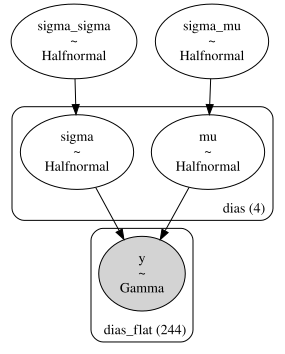

In [ ]:
comparing_groups.to_graphviz()

Tomamos samples de la posterior y extendemos hacia la posterior predictiva:

In [ ]:
with comparing_groups:
    idata_cg = pm.sample(chains=4, tune=1000, target_accept=0.9)
    idata_cg.extend(pm.sample_posterior_predictive(idata_cg))

Y observamos el gráfico al igual que hicimos en el ejemplo original:

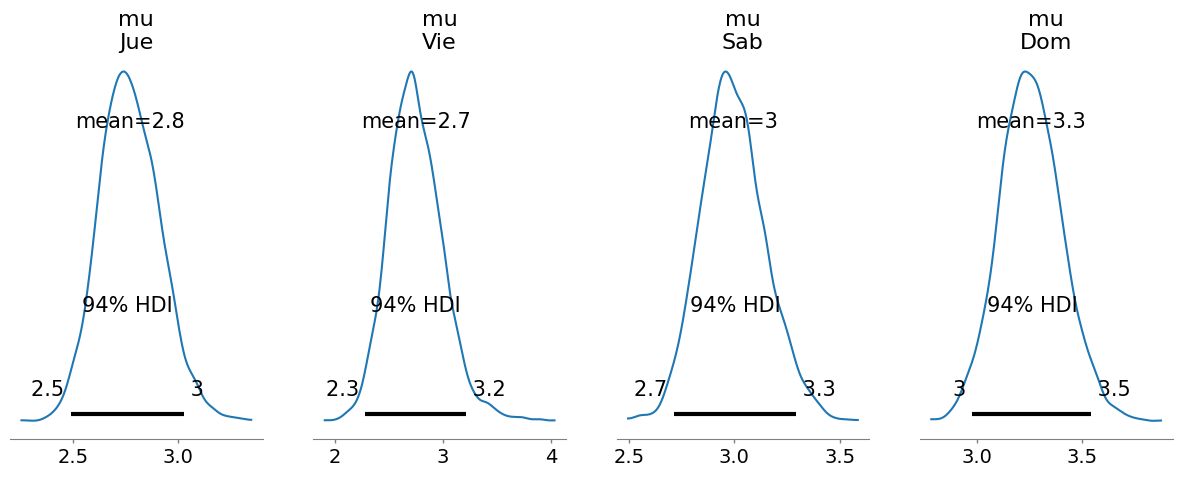

In [ ]:
ax = az.plot_posterior(idata_cg, var_names=["mu"], figsize=(15, 5));

En lineas generales **no hubieron muchos cambios** pero hay que notar las diferencias en la media estimada para el día Viernes, la cual **pasó de 2.8 en el modelo original a 2.7**. Además si prestamos atención a los HDI podemos notar que estos comprenden rangos más pequeños para los días Jueves y Viernes.

Para darle más sentido a estos cambios puntuales en los días Jueves y Viernes observemos la cantidad de información que tenemos para dichos días:

In [ ]:
tips.dia.value_counts()

,count
dia,
Sab,87
Dom,76
Jue,62
Vie,19


Podemos notar que **justo son los días con menor cantidad de datos**, siendo el Viernes el que menor cantidad tiene y que justo fue el que más cambió en sus estimaciones cuando consideramos la estructura jerárquica. Esto deja ver el **efecto de información compartida** que dan estos modelos, en donde el grupo más pequeño logró predicciones más conservadoras y de menor incertidumbre gracias a la información observada en otros días.

### 6. Cuando se utilizan distribuciones a priori débilmente informativas, las predicciones medias a posteriori de un modelo normal-normal jerárquico son (aproximadamente) promedios pesados de la siguiente forma: $\frac{\sigma^2_y}{\sigma^2_y + n_j \sigma^2_\mu} \overline{y}_{\text{global}} + \frac{n_j\sigma^2_\mu}{\sigma^2_y + n_j \sigma^2_\mu} \overline{y}_j$. Donde  $\bar{y}_{global}$ es la media de todas las observaciones, $\hat{y}_{j}$ es la media de las observaciones en el grupo $j$, $n_j$ es el número de observaciones en el grupo $j$, $\sigma^2_{y}$ es la varianza de las observaciones y $\sigma^2_{\mu}$ es la varianza de las medias de los grupos. Indique en que condiciones las predicciones a nivel individual se contraeran más hacia la predicción global.

Considerando la fórmula:

$$\frac{\sigma^2_y}{\sigma^2_y + n_j \sigma^2_\mu} \overline{y}_{\text{global}} + \frac{n_j\sigma^2_\mu}{\sigma^2_y + n_j \sigma^2_\mu} \overline{y}_j$$

Se pueden dar los siguientes casos:

**1. Cuando $n_j$ es pequeño:**
- Si $n_j \to 0$, el segundo término se anula: $\frac{n_j\sigma^2_\mu}{\sigma^2_y + n_j \sigma^2_\mu} \to 0$
- El primer término tiende a 1: $\frac{\sigma^2_y}{\sigma^2_y + n_j \sigma^2_\mu} \to 1$
- Por tanto: $\text{predicción} \to \overline{y}_{\text{global}}$

**2. Cuando $\sigma^2_\mu$ es pequeño (baja variabilidad entre grupos):**
- Si $\sigma^2_\mu \to 0$, entonces $\frac{n_j\sigma^2_\mu}{\sigma^2_y + n_j \sigma^2_\mu} \to 0$
- Y $\frac{\sigma^2_y}{\sigma^2_y + n_j \sigma^2_\mu} \to 1$
- Podemos decir que si los grupos son muy similares entre sí, no tiene sentido usar información específica del grupo

**3. Cuando $\sigma^2_y$ es grande (alta variabilidad en las observaciones):**
- Si $\sigma^2_y \to \infty$, el segundo término se anula: $\frac{n_j\sigma^2_\mu}{\sigma^2_y + n_j \sigma^2_\mu} \to 0$
- Siguiendo en la misma, para el primer término $\frac{\sigma^2_y}{\sigma^2_y + n_j \sigma^2_\mu}$ tendríamos una indeterminación $\frac{\infty}{\infty}$, si la resolvemos
usando la regla de L'Hôpital veremos que este tiende a $1$
- Por tanto: $\text{predicción} \to \overline{y}_{\text{global}}$

Para verlo más "empíricamente" a continuación dejo código que simula a estos términos y hace uso de datos
generados para ver el efecto más claramente:

In [ ]:
def prediccion_jerarquica(y_global, y_j, n_j, sigma2_y, sigma2_mu):
    """
    Calcula la predicción jerárquica usando la fórmula del enunciado.

    Parámetros:
    - y_global: media global de todas las observaciones
    - y_j: media del grupo j
    - n_j: número de observaciones en el grupo j
    - sigma2_y: varianza de las observaciones
    - sigma2_mu: varianza de las medias de los grupos

    Retorna:
    - predicción jerárquica ponderada
    """
    peso_global = sigma2_y / (sigma2_y + n_j * sigma2_mu)
    peso_grupo = (n_j * sigma2_mu) / (sigma2_y + n_j * sigma2_mu)

    return peso_global * y_global + peso_grupo * y_j

def analizar_contraccion_jerarquica(param_name, param_values, fixed_params, caso_titulo):
    """
    Función para analizar y visualizar el efecto de contracción jerárquica.

    Parámetros:
    - param_name: nombre del parámetro que varía ('n_j', 'sigma2_mu', 'sigma2_y')
    - param_values: array con los valores del parámetro a probar
    - fixed_params: dict con los parámetros fijos
    - caso_titulo: título para el caso
    - interpretacion: texto explicativo del efecto
    """
    print(f"\n🔍 {caso_titulo}")
    print(f"Parámetros fijos: {fixed_params}")
    print(f"Variamos {param_name}")

    predicciones = []
    pesos_globales = []

    for param_val in param_values:
        # Actualizar parámetros con el valor actual
        current_params = fixed_params.copy()
        current_params[param_name] = param_val

        # Calcular predicción
        pred = prediccion_jerarquica(
            y_global, y_j,
            current_params['n_j'],
            current_params['sigma2_y'],
            current_params['sigma2_mu']
        )
        predicciones.append(pred)

        # Calcular peso global
        peso_global = current_params['sigma2_y'] / (current_params['sigma2_y'] +
                                                   current_params['n_j'] * current_params['sigma2_mu'])
        pesos_globales.append(peso_global)

        print(f"{param_name}={param_val:>6}: predicción={pred:6.2f}, peso_global={peso_global:.3f}")

# Configuraciones para diferentes escenarios
y_global = 100  # Media global fija
y_j = 150      # Media del grupo específico (diferente de la global)
sigma2_y = 25  # Varianza base de observaciones

print(f"Configuración base:")
print(f"Media global: {y_global}")
print(f"Media del grupo j: {y_j}")
print(f"Varianza observaciones (σ²_y): {sigma2_y}")

Configuración base:
Media global: 100
Media del grupo j: 150
Varianza observaciones (σ²_y): 25


In [ ]:
n_j_values = np.array([200, 100, 50, 20, 10, 5, 2, 1])
fixed_params_caso1 = {'sigma2_mu': 10, 'sigma2_y': sigma2_y}

analizar_contraccion_jerarquica(
    param_name='n_j',
    param_values=n_j_values,
    fixed_params=fixed_params_caso1,
    caso_titulo='CASO 1: Efecto del tamaño del grupo'
)


🔍 CASO 1: Efecto del tamaño del grupo
Parámetros fijos: {'sigma2_mu': 10, 'sigma2_y': 25}
Variamos n_j
n_j=   200: predicción=149.38, peso_global=0.012
n_j=   100: predicción=148.78, peso_global=0.024
n_j=    50: predicción=147.62, peso_global=0.048
n_j=    20: predicción=144.44, peso_global=0.111
n_j=    10: predicción=140.00, peso_global=0.200
n_j=     5: predicción=133.33, peso_global=0.333
n_j=     2: predicción=122.22, peso_global=0.556
n_j=     1: predicción=114.29, peso_global=0.714


In [ ]:
sigma2_mu_values = np.array([50, 20, 10, 5, 2, 1, 0.5, 0.1])
fixed_params_caso2 = {'n_j': 10, 'sigma2_y': sigma2_y}

analizar_contraccion_jerarquica(
    param_name='sigma2_mu',
    param_values=sigma2_mu_values,
    fixed_params=fixed_params_caso2,
    caso_titulo='CASO 2: Efecto de la variabilidad entre grupos'
)


🔍 CASO 2: Efecto de la variabilidad entre grupos
Parámetros fijos: {'n_j': 10, 'sigma2_y': 25}
Variamos sigma2_mu
sigma2_mu=  50.0: predicción=147.62, peso_global=0.048
sigma2_mu=  20.0: predicción=144.44, peso_global=0.111
sigma2_mu=  10.0: predicción=140.00, peso_global=0.200
sigma2_mu=   5.0: predicción=133.33, peso_global=0.333
sigma2_mu=   2.0: predicción=122.22, peso_global=0.556
sigma2_mu=   1.0: predicción=114.29, peso_global=0.714
sigma2_mu=   0.5: predicción=108.33, peso_global=0.833
sigma2_mu=   0.1: predicción=101.92, peso_global=0.962


In [ ]:
sigma2_y_values = np.array([1, 2, 5, 10, 25, 50, 100, 200])
fixed_params_caso3 = {'n_j': 10, 'sigma2_mu': 10}

analizar_contraccion_jerarquica(
    param_name='sigma2_y',
    param_values=sigma2_y_values,
    fixed_params=fixed_params_caso3,
    caso_titulo='CASO 3: Efecto de la variabilidad observada'
)


🔍 CASO 3: Efecto de la variabilidad observada
Parámetros fijos: {'n_j': 10, 'sigma2_mu': 10}
Variamos sigma2_y
sigma2_y=     1: predicción=149.50, peso_global=0.010
sigma2_y=     2: predicción=149.02, peso_global=0.020
sigma2_y=     5: predicción=147.62, peso_global=0.048
sigma2_y=    10: predicción=145.45, peso_global=0.091
sigma2_y=    25: predicción=140.00, peso_global=0.200
sigma2_y=    50: predicción=133.33, peso_global=0.333
sigma2_y=   100: predicción=125.00, peso_global=0.500
sigma2_y=   200: predicción=116.67, peso_global=0.667


### 7. (Extra) Aplicá uno de los modelos vistos en este capítulo a datos propios o de tu interés.

**La ciencia de datos** es un campo interdisciplinario que ha experimentado un crecimiento **exponencial** en los últimos años, posicionándose como una de las carreras más populares debido a su amplia gama de aplicaciones prácticas y su impacto en diversos sectores.  

En esta oportunidad, el objetivo es estudiar uno de los factores clave que se consideran al evaluar una carrera profesional: **el salario**.  

Para realizar este análisis, se utilizará [un conjunto de datos](https://www.kaggle.com/datasets/yusufdelikkaya/datascience-salaries-2024) que contiene información anonimizada sobre salarios en el ámbito de la ciencia de datos recopilados en los últimos 4 años **(2020 - 2024)**. Este conjunto de datos proporciona información detallada de los elementos que se consideran **influyentes en el salario**, incluyendo niveles de experiencia, tipos de empleo, roles laborales, modalidades de trabajo remoto, ubicaciones geográficas, y más.  

Para efectos prácticos del ejercicio (y por simpleza) al conjunto de datos se le aplicó un preprocesamiento en el script `data_science_salaries.py` para considerar solo a las columnas que informan sobre seniority y ubicación del trabajador, además se filtraron los datos para solo tomar al año 2024. Luego a la variable que mide el salario en dólares se le aplicó una transformación para que esté **en escala logarítmica**. Notar que la idea es implementar el caso que comenté antes en el ejercicio 2.

Sin más, procedemos a cargar los datos y visualizarlos:

[]

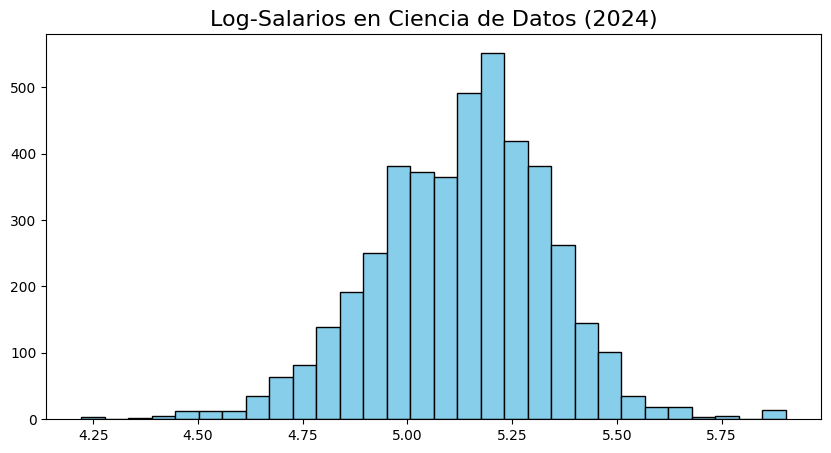

In [32]:
df_salarios_2024 = pd.read_csv("data/processed/data_science_salaries_2024.csv")
plt.figure(figsize=(10, 5))
plt.hist(df_salarios_2024['log_salary_in_usd'], bins=30, color='skyblue', edgecolor='black')
plt.title('Log-Salarios en Ciencia de Datos (2024)', fontsize=16)
plt.plot()

A continuación dejo una serie de puntos donde dejo clara la estructura que planteo para este modelo:

* Los grupos en este modelo estarán definidos por las variables **employee_residence** y **experience_level**. En donde **employee_residence** tiene un nivel jerárquico por encima de **experience_level**.

* La variable objetivo vendrá dada por la distribución: *log_salary_in_usd* $\sim \text{StudentT}(\mu = \mu[i, j], \sigma = \epsilon, \nu= \nu)$ donde **$\mu[i, j]$** es el parámetro que varía según el nivel de seniority $j$ dentro de cada país $i$, $\epsilon$ es la desviación estándar, y $\nu$ son los grados de libertad.

* Como hiperprior para $\mu[i, j]$ (seniority) consideraré a una distribución normal con parámetros $\mu[i]$ y $\sigma[\mu[i, j]]$, los cuales seguirán distribuciones normal y HalfNormal, respectivamente. Notar que para el caso de $\mu[i]$, que representaría el lugar de residencia de un empleado también consideraré como hiperprior a una distribución normal también con parámetros $\mu$ y $\sigma[\mu[i]]$ con distribuciones similares al caso anterior pero con valores débilmente informativos para representar la incertidumbre.

* Los priors asignados a los parámetros $\epsilon$ y $\nu$ serán también **débilmente informativos**, para garantizar que el modelo pueda adaptarse a la variabilidad observada sin imponer fuertes restricciones.

Con todo esto dicho paso a implementar al modelo:

In [ ]:
# Encoding para la residencia
employee_residence_encode = pd.Categorical(df_salarios_2024['employee_residence'])
idx_residence = employee_residence_encode.codes

# Encoding a partir de índice combinado para residence-experience
df_salarios_2024['residence_exp_combo'] = df_salarios_2024['employee_residence'] + '_' + df_salarios_2024['experience_level']
residence_exp_combo = pd.Categorical(df_salarios_2024['residence_exp_combo'])
idx_combo = residence_exp_combo.codes

# Coordenadas 
coords = {
    'employee_residence': employee_residence_encode.categories,
    'residence_exp_combo': residence_exp_combo.categories,
    'obs': range(len(df_salarios_2024))
}

# Definir el modelo jerárquico
with pm.Model(coords=coords) as modelo_salarios_jerarquico:

    # NIVEL 1: Hiperparámetros globales (más alto)
    mu_global = pm.Normal("mu_global", mu=5, sigma=1)
    sigma_global = pm.HalfNormal("sigma_global", sigma=0.5)

    # NIVEL 2: Parámetros por residencia/país (segundo nivel)
    mu_residence = pm.Normal(
        "mu_residence",
        mu=mu_global,
        sigma=sigma_global,
        dims="employee_residence"
    )

    # NIVEL 3: Parámetros por experiencia dentro de cada residencia (tercer nivel)
    # Creo matriz de mapeo residence -> experience combinations
    residence_for_combo = []
    for combo in residence_exp_combo.categories:
        residence = combo.split('_')[0]
        residence_idx = list(employee_residence_encode.categories).index(residence)
        residence_for_combo.append(residence_idx)
        
    sigma_seniority = pm.HalfNormal("sigma_seniority", sigma=0.3)
    mu_seniority = pm.Normal(
        "mu_seniority",
        mu=mu_residence[residence_for_combo],
        sigma=sigma_seniority,
        dims="residence_exp_combo"
    )

    # Parámetros para la distribución StudentT
    sigma_obs = pm.HalfNormal("sigma_obs", sigma=0.2)  
    nu = pm.Exponential("nu", lam=1/30) 

    # LIKELIHOOD: Observaciones usando StudentT
    log_salary_obs = pm.StudentT(
        "log_salary_obs",
        mu=mu_seniority[idx_combo],
        sigma=sigma_obs,
        nu=nu,
        observed=df_salarios_2024['log_salary_in_usd'].values,
        dims="obs"
    )

Bueno, pasaron muchas cosas pero seguramente la más llamativa ocurrió entre estas lineas de código:

```python
residence_for_combo = []
for combo in residence_exp_combo.categories:
    residence = combo.split('_')[0]
    residence_idx = list(employee_residence_encode.categories).index(residence)
    residence_for_combo.append(residence_idx)

sigma_seniority = pm.HalfNormal("sigma_seniority", sigma=0.3)
mu_seniority = pm.Normal(
    "mu_seniority",
    mu=mu_residence[residence_for_combo],
    sigma=sigma_seniority,
    dims="residence_exp_combo"
)
```

**¿Por qué esto es necesario?**
- Creas combinaciones únicas como `"US_Senior"`, `"Argentina_Junior"`, etc.
- Cada combinación será un grupo específico en el nivel más bajo de la jerarquía
- PyMC necesita índices únicos para mapear observaciones a parámetros

**Este es el corazón del enfoque jerárquico:**
- Para cada combinación `"País_Experiencia"`, extrae solo el `"País"`
- Encuentra el índice de ese país en la lista de países
- Crea un array que mapea: `combinación → país_padre`

**Ejemplo:**
```python
Combinaciones:     ["US_Senior", "US_Junior", "Argentina_Senior", "Argentina_Junior"]
residence_for_combo: [0,         0,           1,                  1                ]
```
**Esto da como resultado que ocurra lo siguiente:**

`mu_residence[residence_for_combo]` usa el mapeo para decir:
   - El parámetro para `"US_Senior"` hereda de `mu_residence[US]`
   - El parámetro para `"US_Junior"` también hereda de `mu_residence[US]`
   - El parámetro para `"Argentina_Senior"` hereda de `mu_residence[Argentina]`

Luego de esta explicación, pasemos a ver la estructura del modelo:

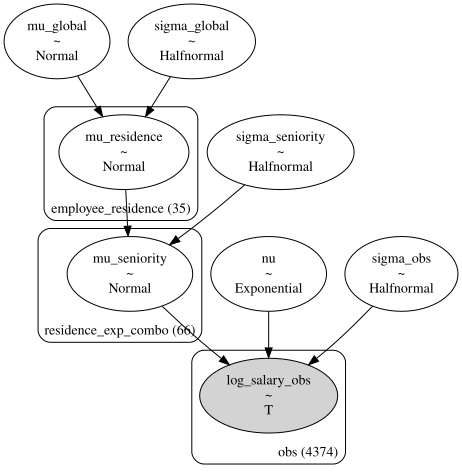

In [ ]:
modelo_salarios_jerarquico.to_graphviz()

Tomamos samples de la posterior:

In [ ]:
with modelo_salarios_jerarquico:
    idata_salarios = pm.sample(
        draws=2000,
        tune=1000,
        chains=4,
        target_accept=0.95,
        random_seed=42
    )

Output()

Ya que estimamos un montón de parámetros vamos a limitarnos a ver solo a los más generales:

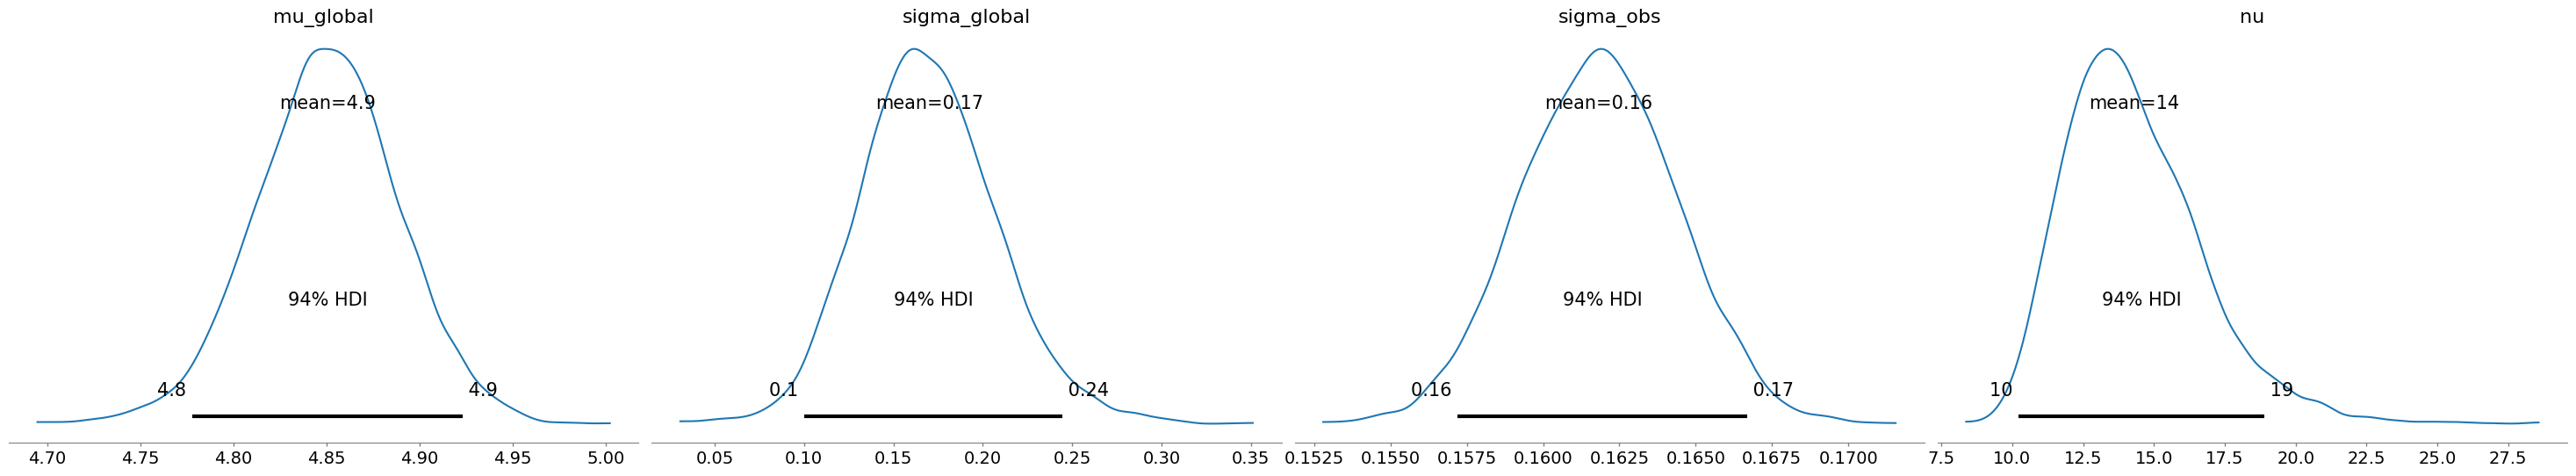

In [ ]:
az.plot_posterior(idata_salarios, var_names=["mu_global", "sigma_global", "sigma_obs", "nu"])
plt.tight_layout()
plt.show()

Podemos usar un **forest plot** para visualizar todas las estimaciones. Empezamos por la residencia:

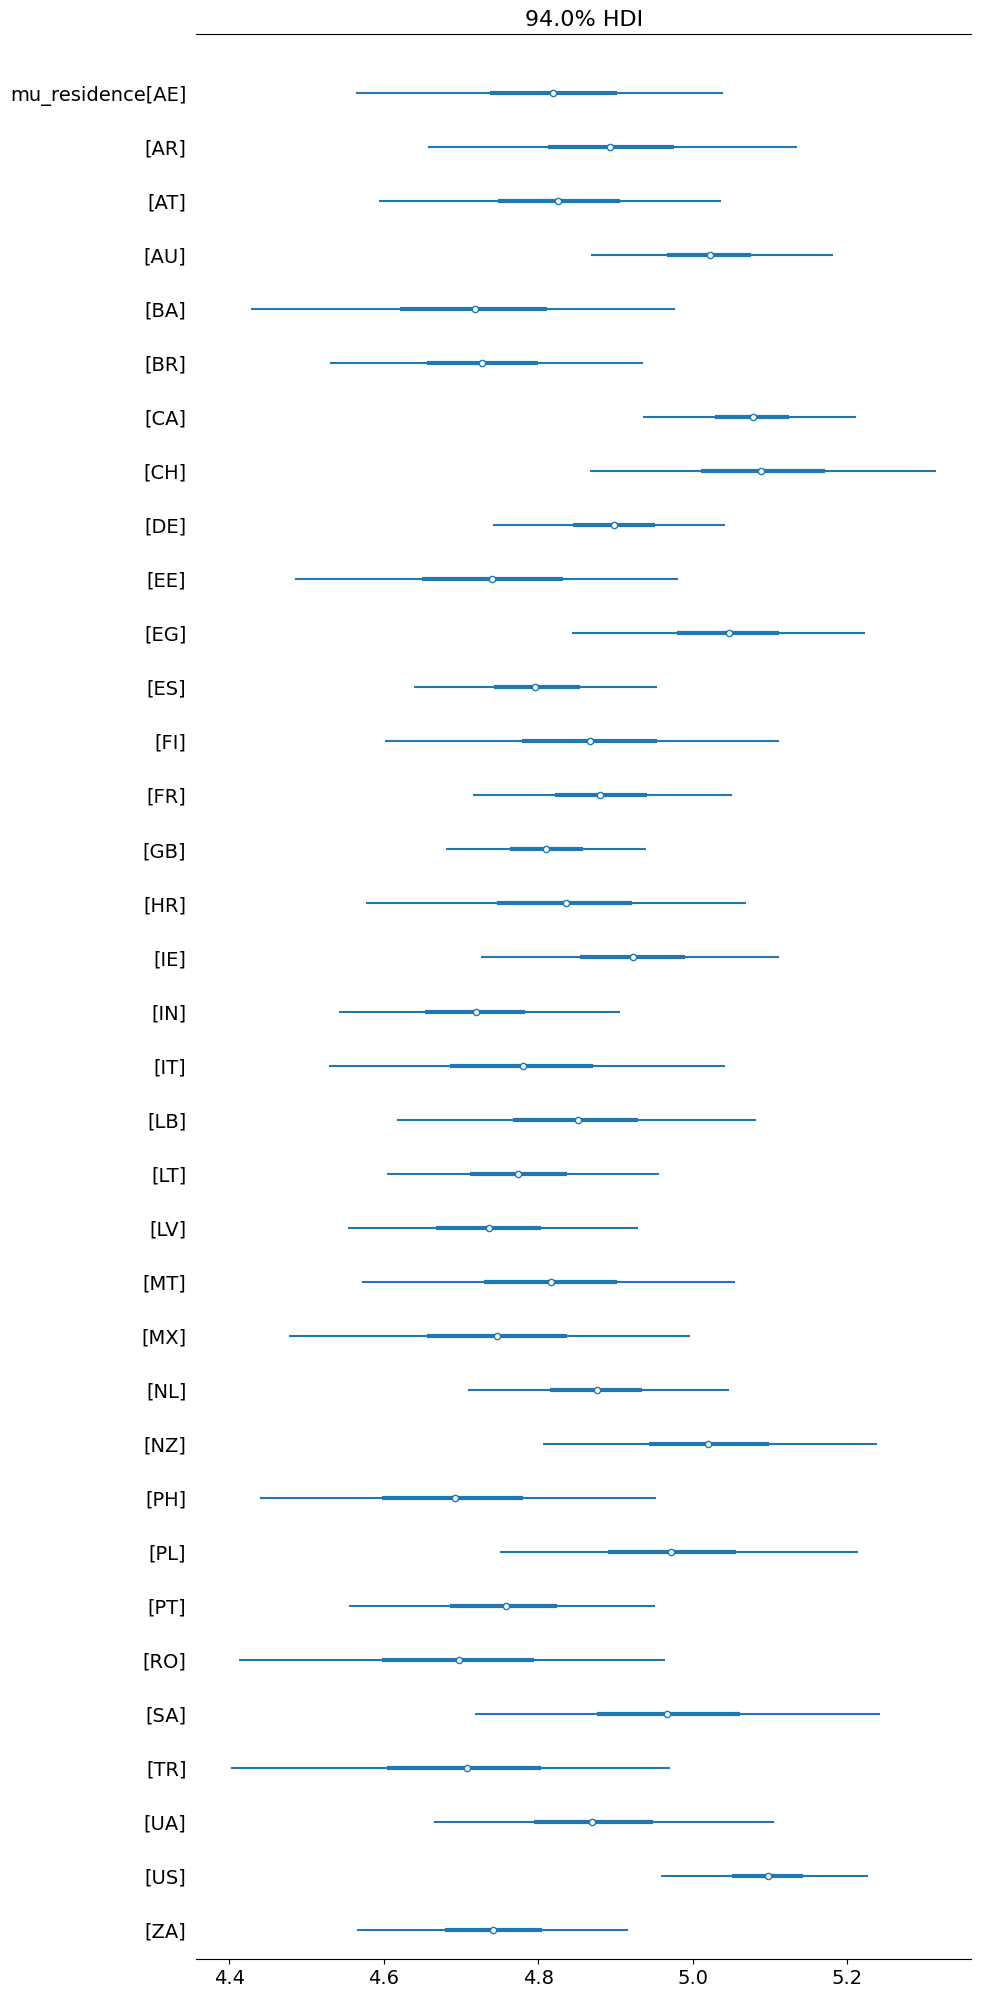

In [ ]:
az.plot_forest(
    idata_salarios,
    var_names=["mu_residence"],
    combined=True,
    r_hat=False,
    figsize=(10, 25)
)
plt.show()

Vemos ahora la combinación **residencia-seniority**:

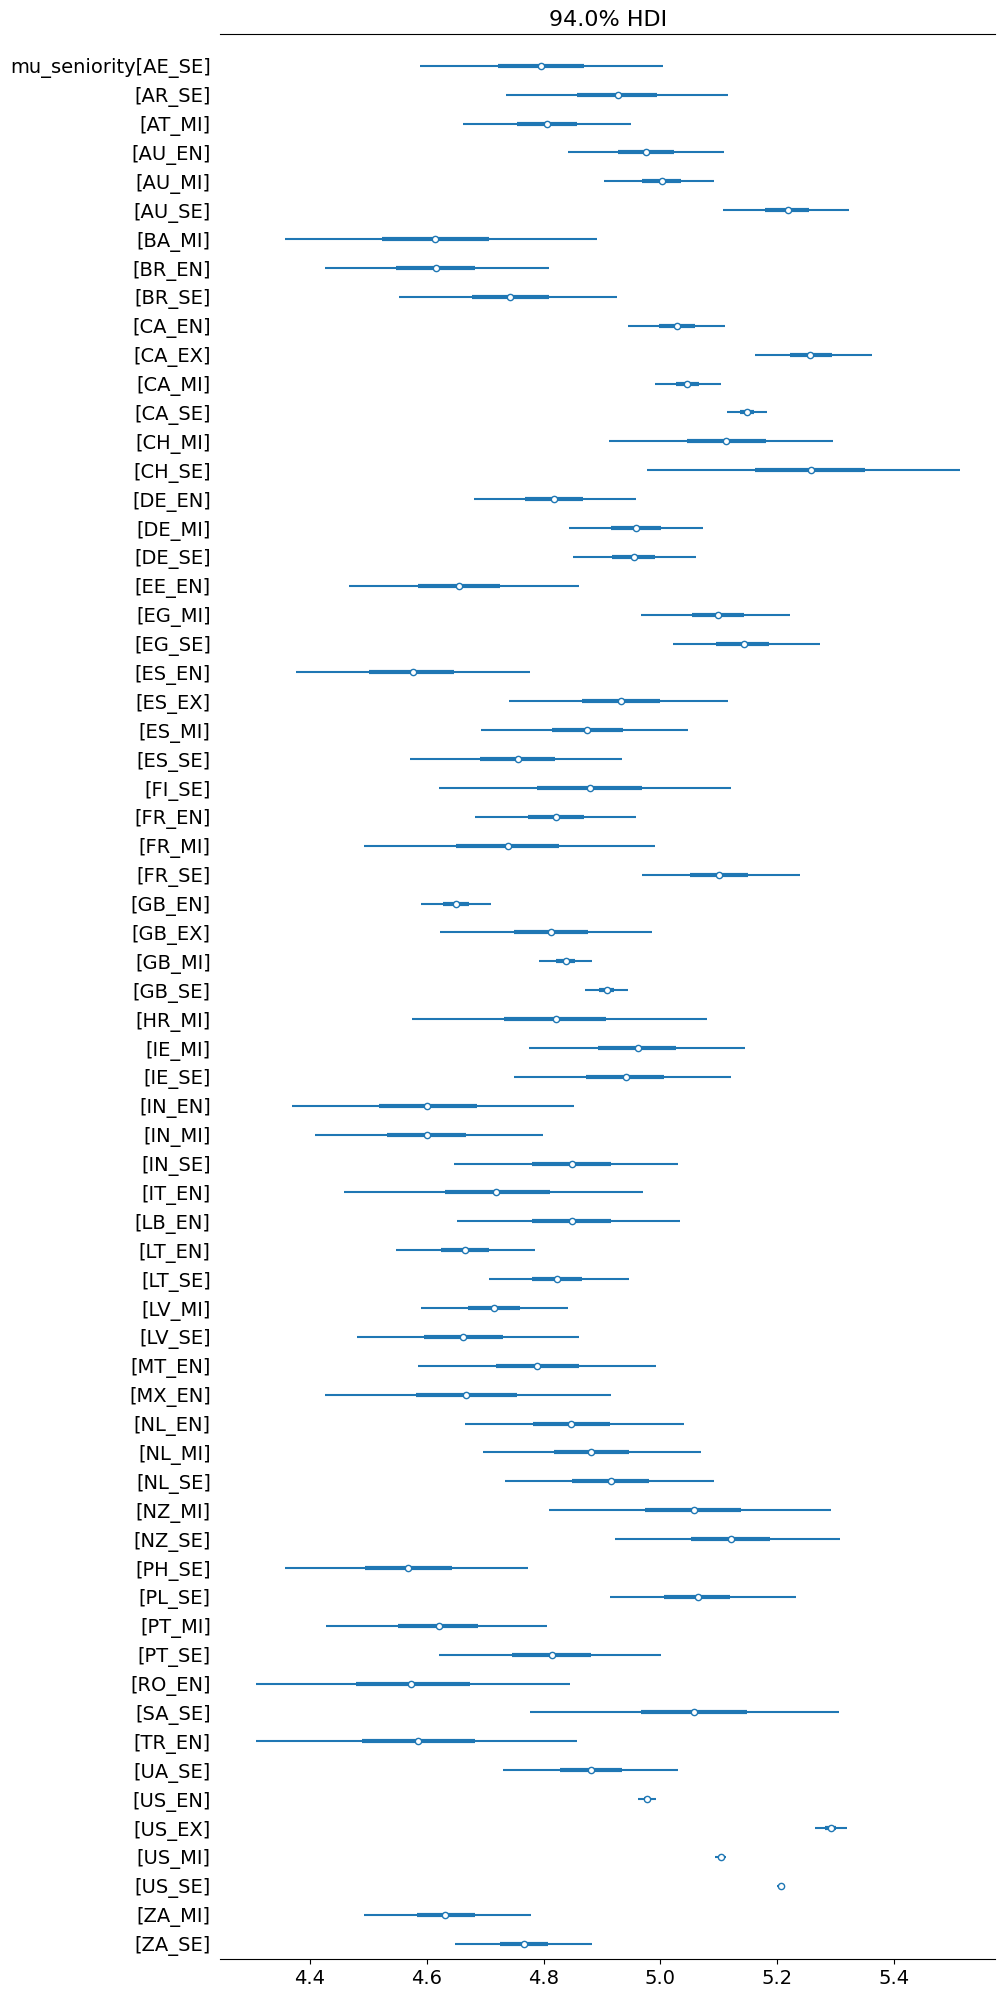

In [ ]:
az.plot_forest(
    idata_salarios,
    var_names=["mu_seniority"],
    combined=True,
    r_hat=False,
    figsize=(10, 25)
)
plt.show()

Ya con todo lo observado podemos decir que obtuvimos un montón de estimaciones para un montón de combinaciones posibles entre país-seniority. Luego queda hacer un análisis extenso de los resultados, reescalar los datos para verlos en su versión original y analizar si son coherentes pero más allá de eso **la idea de hacer esto es probar como sería un modelo jerárquico con más de un nivel**. 